In [1]:
import pandas as pd
import os
import time
import re
from pathlib import Path
import pandasai as pai
from pandasai_litellm.litellm import LiteLLM
from litellm import completion

In [2]:
df_clinic_level = pd.read_csv("cc_clinic_level.csv")
df_doctor = pd.read_csv("cc_doctor.csv")
df_hourly = pd.read_csv("cc_hourly.csv")
df_patient = pd.read_csv("cc_patient.csv")

df_clinic_level = pai.DataFrame(df_clinic_level)
df_doctor = pai.DataFrame(df_doctor)
df_hourly = pai.DataFrame(df_hourly)
df_patient = pai.DataFrame(df_patient)

In [3]:
def generate_Response(question: str, dataframes: list, model_id: str = None, api_key: str = None):
    """
    Generate a response using PandasAI for the given question.
    
    Args:
        question: The question to ask
        dataframes: List of PandasAI DataFrames to query
        model_id: The LLM model identifier
        api_key: API key for the LLM
    
    Returns:
        tuple: (response, elapsed_time)
    """
    default_api_key = "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"
    default_model = "nvidia_nim/google/gemma-3-27b-it"
    
    # Configure the LLM
    llm = LiteLLM(
        model=model_id or default_model,
        api_key=api_key or default_api_key,
        stream=False,
    )
    pai.config.set({"llm": llm, "save_charts": False})
    
    start_time = time.time()
    response = pai.chat(question, *dataframes)
    elapsed_time = time.time() - start_time
    
    return response, elapsed_time

In [4]:
def extract_Generated_code(log_path: str = "pandasai.log"):
    """
    Extract the full generated code from PandasAI log.
    
    Returns:
        dict: {"sql_query": str, "full_code": str}
    """
    from pathlib import Path
    
    log_file = Path(log_path)
    if not log_file.exists():
        return {"sql_query": "", "full_code": ""}
    
    text = log_file.read_text(encoding="utf-8")
    
    # --- Extract full generated code from "Executing code:" section ---
    full_code = ""
    # Pattern to find code after "Executing code:" until next log entry or end
    exec_pattern = r'\[INFO\] Executing code:\s*(.+?)(?=\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2} \[INFO\]|$)'
    exec_matches = re.findall(exec_pattern, text, re.DOTALL)
    if exec_matches:
        full_code = exec_matches[-1].strip()
    
    # --- Extract SQL query from the full code ---
    sql_query = ""
    # Pattern for triple-quoted multi-line SQL
    multi_line_pattern = r'sql_query\s*=\s*"""(.+?)"""'
    single_quote_pattern = r"sql_query\s*=\s*'([^']+)'"
    double_quote_pattern = r'sql_query\s*=\s*"([^"]+)"'

    # Search in full_code first, then in entire text
    search_text = full_code if full_code else text
    
    matches = re.findall(multi_line_pattern, search_text, re.DOTALL)
    if not matches:
        matches = re.findall(single_quote_pattern, search_text)
    if not matches:
        matches = re.findall(double_quote_pattern, search_text)
    if matches:
        sql_query = matches[-1].strip()
    
    return {"sql_query": sql_query, "full_code": full_code}


def clear_log(log_path: str = "pandasai.log"):
    """Clear the PandasAI log file after extraction."""
    from pathlib import Path
    log_file = Path(log_path)
    if log_file.exists():
        log_file.write_text("", encoding="utf-8")

In [5]:
def validation_Response(query: str, question: str,response=None,answer=None) -> bool:
    if not query:
        return False
    
    try:
        validation = completion(
            model="nvidia_nim/meta/llama-3.1-405b-instruct",
            messages=[{
                "role": "user", 
                "content": f"""You are a query validator.
                Question: {question}
                Code: {query}
                response: {response} if response is chart or visualization, compare answer with the query else compare response with the answer
                answer: {answer}
                Does this code correctly retrieve the data required to answer the question?
                Respond with ONLY one word: TRUE or FALSE."""
            }],
            api_key= "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"
            
        )
        return validation.choices[0].message.content.strip()
        
    except Exception as e:
        print(f"⚠️ Validation error: {e}")
        return None

In [6]:
def error_explaination_Response(query: str, question: str, response=None, answer=None) -> str:
    if not query:
        return "No code generated to validate."
    
    try:
        explanation = completion(
            model="nvidia_nim/meta/llama-3.1-405b-instruct",
            messages=[{
                "role": "user", 
                "content": f"""You are a helpful assistant that explains errors in code.
                Question: {question}
                Code: {query}
                Response: {response}
                Answer: {answer}
                the code is determine by the llms judge passed to you thats means it is wrong, explain what is wrong with it and how to fix it. If the code is correct, say "The code is correct."."""
            }],
            api_key= "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"
        )
        return explanation.choices[0].message.content.strip()
        
    except Exception as e:
        print(f"⚠️ Explanation error: {e}")
        return "An error occurred while generating the explanation."

In [33]:
clear_log()
# Simple test using the helper functions
question = "Which clinic serves the highest number of patients from different countries, and which doctor handles the majority of those patients?"

# Use generate_Response function
response, elapsed_time = generate_Response(question, [df_doctor, df_hourly, df_patient,df_clinic_level])
print(f"Response: {response.value if hasattr(response, 'value') else response}")

# Extract full generated code
generated = extract_Generated_code()
print(f"\nSQL Query:\n{generated['sql_query']}")
print(f"\nFull Code:\n{generated['full_code']}")

# Use validation_Response function with full_code for complete validation
code_to_validate = generated['full_code'] if generated['full_code'] else generated['sql_query']
is_correct = validation_Response(code_to_validate, question, response=response, answer=""""DOCTOR HE treats 1,996 patients at CLINIC T.""")
print(f"\nIs Correct: {is_correct}")

# Check if validation returned "FALSE" (string comparison, case-insensitive)
if is_correct and "false" in str(is_correct).lower():
    explanation = error_explaination_Response(code_to_validate, question, response,answer)
    print(f"\nError Explanation:\n{explanation}")

print(f"Time taken: {elapsed_time:.2f} seconds")

Response: Unfortunately, I was not able to get your answer. Please try again.

SQL Query:
SELECT
  t1.IDOrganisation,
  t1.StaffName,
  COUNT(t3.PatientCount) AS TotalPatients
FROM table_c83679f393c19ab82f71054c6c3facb6 AS t1
JOIN table_3586b23a0be349f88985d8c0d783b36d AS t3
  ON t1.IDOrganisation = t3.IDOrganisation
WHERE
  t3.CountriesGeography != 'Malaysia'
GROUP BY
  t1.IDOrganisation,
  t1.StaffName
ORDER BY
  TotalPatients DESC
LIMIT 1;

Full Code:
import pandas as pd
sql_query = """
SELECT
  t1.IDOrganisation,
  t1.StaffName,
  COUNT(t3.PatientCount) AS TotalPatients
FROM table_c83679f393c19ab82f71054c6c3facb6 AS t1
JOIN table_3586b23a0be349f88985d8c0d783b36d AS t3
  ON t1.IDOrganisation = t3.IDOrganisation
WHERE
  t3.CountriesGeography != 'Malaysia'
GROUP BY
  t1.IDOrganisation,
  t1.StaffName
ORDER BY
  TotalPatients DESC
LIMIT 1;
"""
result_df = execute_sql_query(sql_query)
if not result_df.empty:
    clinic = result_df['IDOrganisation'].iloc[0]
    doctor = result_df['StaffN

NameError: name 'answer' is not defined

Response: exports\charts\temp_chart_f8e31945-e1bc-47f6-90a9-ac74381f99ac.png

SQL Query:
SELECT
  t1.StaffName,
  SUM(t1.TotalPatientCount) AS TotalPatients
FROM table_c83679f393c19ab82f71054c6c3facb6 AS t1
JOIN (
  SELECT
    IDOrganisation
  FROM table_c83679f393c19ab82f71054c6c3facb6
  GROUP BY
    IDOrganisation
  ORDER BY
    SUM(TotalRevenue) DESC
  LIMIT 1
) AS t2
  ON t1.IDOrganisation = t2.IDOrganisation
GROUP BY
  t1.StaffName
ORDER BY
  TotalPatients DESC
LIMIT 5;

Full Code:
import pandas as pd
import matplotlib.pyplot as plt
sql_query = """
SELECT
  t1.StaffName,
  SUM(t1.TotalPatientCount) AS TotalPatients
FROM table_c83679f393c19ab82f71054c6c3facb6 AS t1
JOIN (
  SELECT
    IDOrganisation
  FROM table_c83679f393c19ab82f71054c6c3facb6
  GROUP BY
    IDOrganisation
  ORDER BY
    SUM(TotalRevenue) DESC
  LIMIT 1
) AS t2
  ON t1.IDOrganisation = t2.IDOrganisation
GROUP BY
  t1.StaffName
ORDER BY
  TotalPatients DESC
LIMIT 5;
"""
df = execute_sql_query(sql_query)
plt.figure(

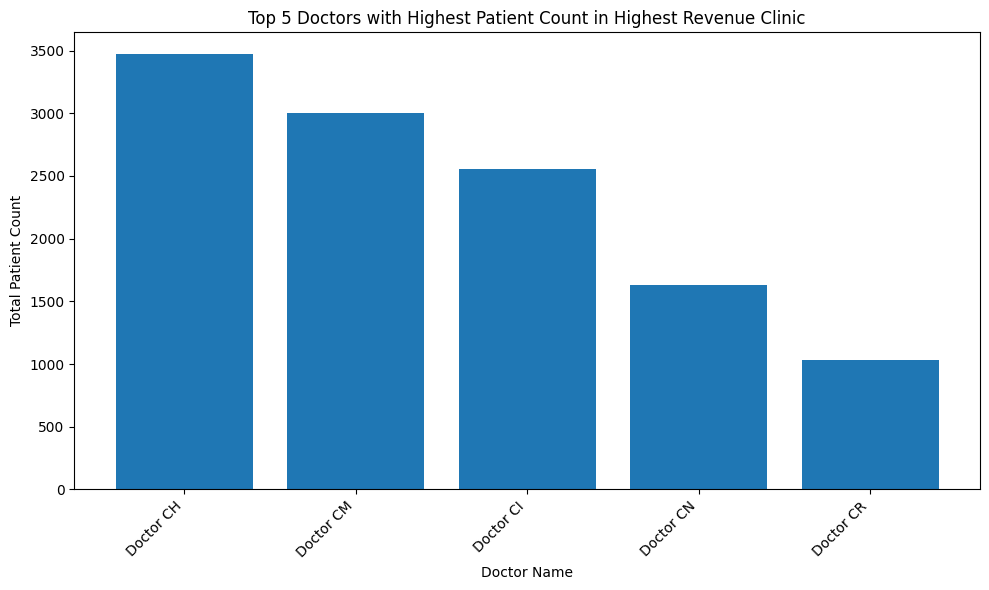

In [14]:
clear_log()
# Simple test using the helper functions
question = "Plot the the top 5 high patient count doctors working  where working in highest revenue Clinic?"

# Use generate_Response function
response, elapsed_time = generate_Response(question, [df_doctor, df_hourly, df_patient,df_clinic_level])
print(f"Response: {response.value if hasattr(response, 'value') else response}")

# Extract full generated code
generated = extract_Generated_code()
print(f"\nSQL Query:\n{generated['sql_query']}")
print(f"\nFull Code:\n{generated['full_code']}")

# Use validation_Response function with full_code for complete validation
code_to_validate = generated['full_code'] if generated['full_code'] else generated['sql_query']
is_correct = validation_Response(code_to_validate, question, response=response)
print(f"\nIs Correct: {is_correct}")

# Check if validation returned "FALSE" (string comparison, case-insensitive)
if is_correct and "false" in str(is_correct).lower():
    explanation = error_explaination_Response(code_to_validate, question, response)
    print(f"\nError Explanation:\n{explanation}")

print(f"Time taken: {elapsed_time:.2f} seconds")

In [ ]:
easy_questions = [
    "Which clinic has the highest TotalRevenue?",
    "What is the average TotalRevenue across all clinics?",
    "List all unique Districts present in the dataset.",
    "Which hour has the highest patient count?",
    "Which state generates the highest total revenue?"
]

medium_questions = [#doctor, patient
    "Which doctor treats the highest number of patients from Malay ethnicity?",
    "Which doctor sees the most patients from  Married social status group?",
    "Which doctor has the highest number of patients from different country/geography?"
    "Which clinic has the highest revenue and how many doctors work there?"
    "Which doctor who treats the highest number of patients from Malay ethnicity in the highest revenue clinic ?"
]

hard_questions = [
    "Create a pie chart of patient religions for the top 3 clinics by total revenue. Analyze religious demographics within high performing clinics.",
    "Plot the relationship between a clinic's total revenue and the number of doctors it employs.",
    "Create a violin plot of revenue. Separate data by Locum or Residence status. Compare earnings."
    "Create a stacked bar chart of patient religion counts by state. Visualize religious demographics in regions."
    "Plot the clinics with the highest revenue and the top 5 high patient count doctors working there?"
]


In [ ]:
answer = [
#easy
"CLINIC I",
"The average TotalRevenue across all clinics is 1,220,906.65.",
"CLINIC I has the highest TotalRevenue of 3,487,368.95.",
"Unique districts include Bandar Enstek, Bangi, Batang Kali, Batu Caves, Bayan Lepas, Central KL, Cheras, Desa Pandan, Dungun, Georgetown, Hulu Langat, Ipoh, Kajang, Kota Bharu, Kuala Langat, Kuala Lumpur, Kuantan, Kulim, Mantin, Muar, Pasir Mas, Petaling, Petaling Jaya, Presint 8, Rawang, Semenyih, Sepang, Seremban, Setia Alam, Shah Alam, Skudai, and Wakaf Bharu.",
"2025-02-13 18:00:00.",
"Kuala Lumpur generates the highest total revenue.",
#medium
"Doctor B treats the most Malay patients.",
"Doctor BZ treats the most Married patients.",
"Doctor AW treats the most patients from Australia, Bangladesh, Canada, Germany, India, Japan, Malaysia, Philippines, and Singapore.",
"The clinic with the highest revenue is Clinic I with 15 doctors"
]